In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# 2. Load the Datasets
job_df = pd.read_csv("../data/raw/job_description_dataset.csv")
resume_df = pd.read_csv("../data/raw/resume_dataset.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
# 3. Check Dataset Shapes
print("Job Dataset Shape:", job_df.shape)
print("Resume Dataset Shape:", resume_df.shape)

Job Dataset Shape: (1068, 7)
Resume Dataset Shape: (10174, 5)


In [4]:
# 4. View Column Names
print("Job Dataset Columns")
print(job_df.columns)

print("\nResume Dataset Columns")
print(resume_df.columns)

Job Dataset Columns
Index(['JobID', 'Title', 'ExperienceLevel', 'YearsOfExperience', 'Skills',
       'Responsibilities', 'Keywords'],
      dtype='str')

Resume Dataset Columns
Index(['Role', 'Resume', 'Decision', 'Reason_for_decision', 'Job_Description'], dtype='str')


In [5]:
# 5. Display First Five Rows
print("Job Dataset")
display(job_df.head())

print("Resume Dataset")
display(resume_df.head())

Job Dataset


,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
0,NET-F-001,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Framework; .NET Core fundamentals; ASP.NET; MVC; HTML; CSS; JavaScript b...,Assist in coding and debugging applications; Learn and apply .NET Framework and Core fundamental...,.NET; C#; ASP.NET MVC; Entity Framework; SQL Server; LINQ; Visual Studio; Unit Testing
1,NET-F-002,.NET Developer,Fresher,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTML; CSS; JavaScript basics; SQL Server; Entity Fram...,Write simple C# programs under guidance; Support development of ASP.NET MVC applications; Implem...,.NET; C#; ASP.NET MVC; Entity Framework; SQL Server; Razor; Unit Testing
2,NET-F-003,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTML; CSS; JavaScript basics; SQL Server; Git,Contribute to development of small modules; Assist in bug fixing and debugging; Learn and implem...,.NET; C#; ASP.NET MVC; SQL Server; Entity Framework; Git
3,NET-F-004,.NET Developer,Fresher,0-1,C#; .NET Framework; ASP.NET basics; SQL Server; HTML; CSS; LINQ; Visual Studio,Support in software design documentation; Assist senior developers in testing; Create small UI c...,.NET; C#; SQL Server; Entity Framework; ASP.NET
4,NET-F-005,.NET Developer,Fresher,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL Server; HTML; CSS; JavaScript basics,Learn to design and build ASP.NET applications; Assist in connecting apps to SQL Server; Work on...,.NET; C#; ASP.NET MVC; Entity Framework; SQL Server


Resume Dataset


,Role,Resume,Decision,Reason_for_decision,Job_Description
0,E-commerce Specialist,Here's a professional resume for Jason Jones:\n\nJason Jones\nE-commerce Specialist\n\nContact I...,reject,Lacked leadership skills for a senior position.,"Be part of a passionate team at the forefront of machine learning as a E-commerce Specialist, de..."
1,Game Developer,Here's a professional resume for Ann Marshall:\n\nAnn Marshall\nContact Information:\n\n* Email:...,select,Strong technical skills in AI and ML.,"Help us build the next-generation products as a Game Developer and work with a dynamic, cross-fu..."
2,Human Resources Specialist,Here's a professional resume for Patrick Mcclain:\n\nPatrick Mcclain\nHuman Resources Specialist...,reject,Insufficient system design expertise for senior role.,We need a Human Resources Specialist to enhance our team's technical capabilities and contribute...
3,E-commerce Specialist,Here's a professional resume for Patricia Gray:\n\nPatricia Gray\nContact Information:\n\n* Emai...,select,Impressive leadership and communication abilities.,"Be part of a passionate team at the forefront of cloud computing as a E-commerce Specialist, del..."
4,E-commerce Specialist,Here's a professional resume for Amanda Gross:\n\nAmanda Gross\nContact Information:\n\n* Email:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce Specialist to join our team and help drive groundbr...


In [6]:
# 6. Dataset Information
print("Job Dataset Information")
job_df.info()

print("\nResume Dataset Information")
resume_df.info()

Job Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   JobID              1068 non-null   str  
 1   Title              1067 non-null   str  
 2   ExperienceLevel    1068 non-null   str  
 3   YearsOfExperience  1068 non-null   str  
 4   Skills             1068 non-null   str  
 5   Responsibilities   1068 non-null   str  
 6   Keywords           1068 non-null   str  
dtypes: str(7)
memory usage: 58.5 KB

Resume Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10174 entries, 0 to 10173
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Role                 10174 non-null  str  
 1   Resume               10174 non-null  str  
 2   Decision             10174 non-null  str  
 3   Reason_for_decision  10174 non-null  str  
 4   Job_Descript

In [7]:
# 7. Missing Values
print("Missing Values in Job Dataset")
display(job_df.isnull().sum())

print("Missing Values in Resume Dataset")
display(resume_df.isnull().sum())

Missing Values in Job Dataset


JobID                0
Title                1
ExperienceLevel      0
YearsOfExperience    0
Skills               0
Responsibilities     0
Keywords             0
dtype: int64

Missing Values in Resume Dataset


Role                   0
Resume                 0
Decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64

In [8]:
# 8. Duplicate Records
print("Duplicate Job Records:", job_df.duplicated().sum())
print("Duplicate Resume Records:", resume_df.duplicated().sum())

Duplicate Job Records: 0
Duplicate Resume Records: 0


In [9]:
# 9. Target Class Distribution
resume_df["Decision"].value_counts()

Decision
reject    5114
select    5060
Name: count, dtype: int64

In [10]:
decision_distribution = (
    resume_df["Decision"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Decision Distribution (%)")
display(decision_distribution)

Decision Distribution (%)


Decision
reject    50.27
select    49.73
Name: proportion, dtype: float64

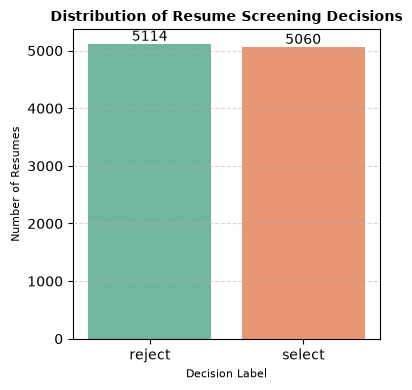

In [11]:
# 9.5. Visualize Target Class Distribution
plt.figure(figsize=(4,4))

ax = sns.countplot(
    data=resume_df,
    x="Decision",
    hue="Decision",
    palette="Set2",
    legend=False
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Distribution of Resume Screening Decisions", fontsize=10, fontweight="bold")
plt.xlabel("Decision Label", fontsize=8)
plt.ylabel("Number of Resumes", fontsize=8)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Summary and Observations

## Job Dataset
- Total Records: **1,068**
- Total Features: **7**
- One missing value was found in the `Title` column.
- All remaining columns are complete and stored as text.

## Resume Dataset
- Total Records: **10,174**
- Total Features: **5**
- No missing values were found.
- All columns are text-based, making the dataset suitable for NLP preprocessing.

## Target Variable
- Target Column: **Decision**
- Classes:
  - Select: **5,060**
  - Reject: **5,114**

The target classes are nearly balanced (approximately 50:50), making the dataset suitable for supervised binary classification without additional class-balancing techniques.

## Conclusion
The datasets have been successfully loaded and explored. The next step is to preprocess the textual data by cleaning, normalizing, and removing irrelevant information before feature engineering and model training.